In [1]:
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath("src"))

df = pd.read_csv("Customer.csv")
print(df.head())

   CustomerID  Annual Income (k$)  Spending Score (1-100)
0           1                  15                      39
1           2                  16                      81
2           3                  17                       6
3           4                  18                      77
4           5                  19                      40


In [2]:
df = pd.read_csv("Customer.csv")

print("Original Data:")
print(df.head())

Original Data:
   CustomerID  Annual Income (k$)  Spending Score (1-100)
0           1                  15                      39
1           2                  16                      81
2           3                  17                       6
3           4                  18                      77
4           5                  19                      40


In [3]:
def preprocess(df):
    # Remove missing values
    df = df.dropna()
    return df

df = preprocess(df)

In [4]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values


In [5]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
from scipy.cluster.hierarchy import linkage

Z = linkage(X_scaled, method='ward')

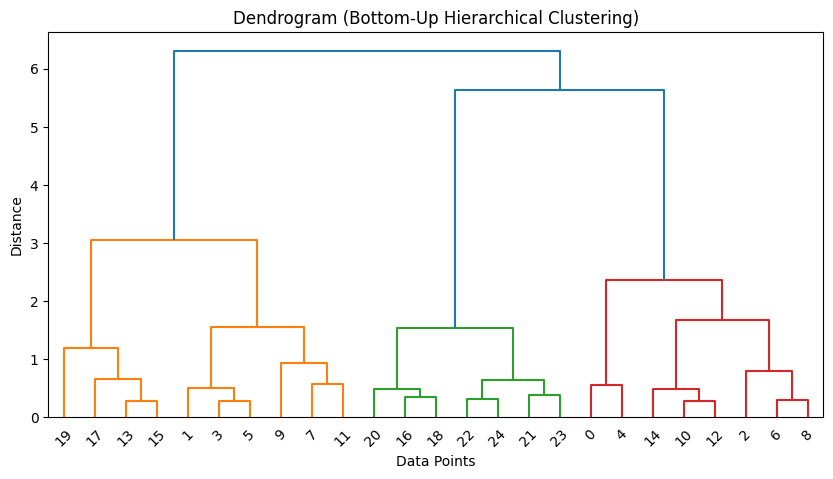

In [14]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram (Bottom-Up Hierarchical Clustering)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [15]:
from sklearn.cluster import BisectingKMeans

def build_topdown_model(n_clusters=3):
    model = BisectingKMeans(n_clusters=n_clusters, random_state=42)
    return model

def get_topdown_clusters(model, X):
    clusters = model.fit_predict(X)
    return clusters

In [17]:
import matplotlib.pyplot as plt

def plot_topdown_clusters(X, clusters):
    plt.figure(figsize=(8, 5))
    
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=clusters,
        cmap="rainbow",
        s=100
    )
    
    plt.xlabel("Annual Income")
    plt.ylabel("Spending Score")
    plt.title("Top-Down Clustering (Bisecting K-Means)")
    
    plt.grid(True, linestyle="--")
    plt.show()